# Titanic Dataset — Data Cleaning & Exploratory Visualization

This notebook continues work on the Titanic dataset. Goals:

1. Handle missing values (with justification for each choice)
2. Detect outliers in a numerical column using a boxplot
3. Build at least 4 visualizations: histogram, boxplot, bar chart, correlation heatmap
4. Answer: *which feature most affects survival, and why?*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/titanic.csv')
df.shape

(891, 12)

## 1. First look at the data

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## 2. Handling missing values

Missing-value counts show three columns with gaps: **Cabin** (687 missing, ~77%), **Age** (177 missing, ~20%), and **Embarked** (2 missing, ~0.2%).

**My choices, and why:**

- **`Cabin` → dropped entirely.** Over three-quarters of the values are missing. There is no reliable way to impute a cabin number, and keeping the column as-is would just be noise. (I do first extract whether a cabin was *recorded at all* as a new binary feature, `HasCabin`, since that presence/absence pattern itself correlates with class and fare, and is worth keeping even though the raw text isn't usable.)
- **`Age` → filled with the median, grouped by `Pclass` and `Sex`.** Age is clearly related to passenger class and sex (e.g., 1st-class passengers skew older), so a single global median would flatten that structure. A `fillna()` grouped by those two columns preserves more realistic values than one blanket number, while still being simple and not requiring us to drop ~20% of the rows (which `dropna()` would force, and Age is too important a predictor to lose that much data over).
- **`Embarked` → filled with the mode.** Only 2 rows are missing out of 891 — far too few to justify dropping, and imputing with the single most common port (`S`) has negligible effect on the analysis.
- **No rows are dropped via `dropna()`** because every column with missing values can be reasonably imputed or replaced with a derived feature, and we don't want to lose ~20% of the dataset by dropping all rows with a missing `Age`.


In [5]:
# Create HasCabin flag before dropping the raw Cabin column
df['HasCabin'] = df['Cabin'].notna().astype(int)

# Age: fill with median grouped by Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: fill with the mode (most frequent port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: drop the raw column (too sparse to use directly)
df = df.drop(columns=['Cabin'])

# Confirm no missing values remain in the columns we care about
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

No more missing values in `Age` or `Embarked`, and `Cabin` has been replaced by the cleaner `HasCabin` flag. `PassengerId`, `Name`, and `Ticket` are identifiers we won't analyze directly.

## 3. Outlier detection with a boxplot

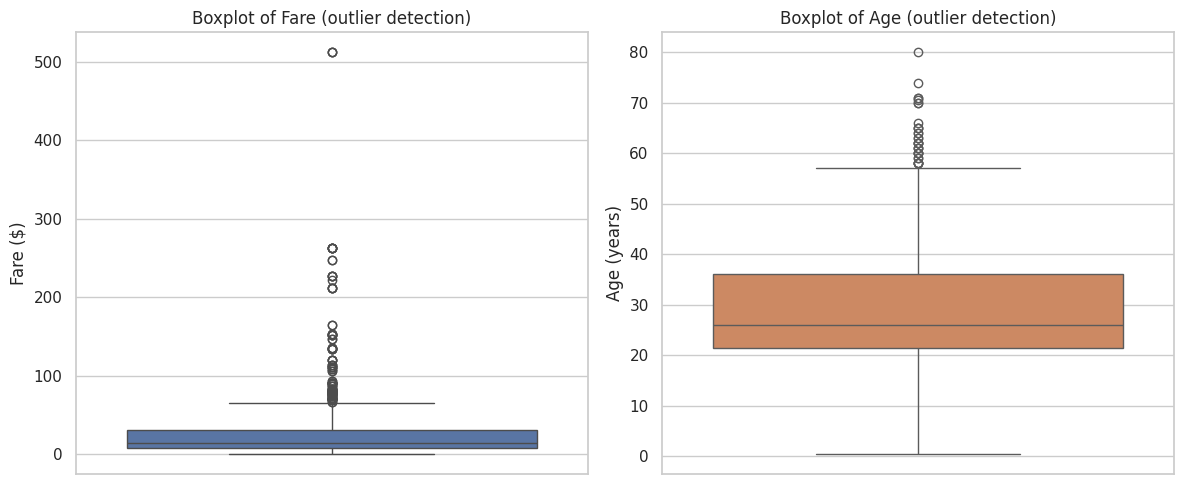

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Fare'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Boxplot of Fare (outlier detection)')
axes[0].set_ylabel('Fare ($)')

sns.boxplot(y=df['Age'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot of Age (outlier detection)')
axes[1].set_ylabel('Age (years)')

plt.tight_layout()
plt.savefig('outputs/boxplot_outliers.png', bbox_inches='tight')
plt.show()

In [7]:
# Quantify outliers in Fare using the IQR rule
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(f"Fare IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of Fare outliers: {len(fare_outliers)} ({len(fare_outliers)/len(df)*100:.1f}% of passengers)")
fare_outliers[['Name', 'Pclass', 'Fare', 'Survived']].sort_values('Fare', ascending=False).head(10)

Fare IQR bounds: [-26.72, 65.63]
Number of Fare outliers: 116 (13.0% of passengers)


,Name,Pclass,Fare,Survived
258,"Ward, Miss. Anna",1,512.3292,1
737,"Lesurer, Mr. Gustave J",1,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
27,"Fortune, Mr. Charles Alexander",1,263.0000,0
341,"Fortune, Miss. Alice Elizabeth",1,263.0000,1
438,"Fortune, Mr. Mark",1,263.0000,0
88,"Fortune, Miss. Mabel Helen",1,263.0000,1
311,"Ryerson, Miss. Emily Borie",1,262.3750,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750,1
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,247.5208,1


**Reading the boxplots:** `Fare` has a long right tail — most tickets cost under \$35, but a cluster of 1st-class passengers paid well over \$100, with a handful above \$500 (these turn out to be a small group traveling together on the same ticket number). These are legitimate values, not data errors, but they are extreme enough to skew means and should be kept in mind for any modeling (e.g., a log transform or robust scaler). `Age` has a much tighter, more symmetric spread with only a few mild outliers among elderly passengers — nothing that looks like a data entry error (no negative ages or ages above ~80).

## 4. Visualizations

### 4.1 Histogram — Age distribution

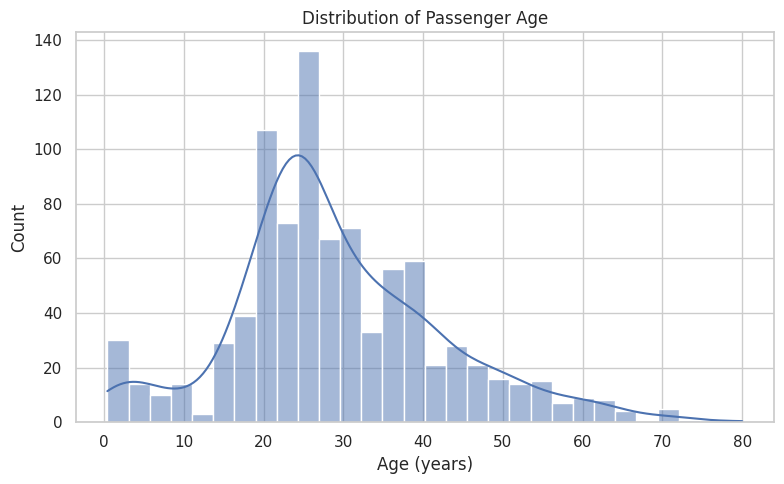

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/histogram_age.png', bbox_inches='tight')
plt.show()

Most passengers were young adults in their 20s–30s, with a smaller bump of infants/young children and a long, thinning tail toward older ages.

### 4.2 Boxplot — Fare by passenger class

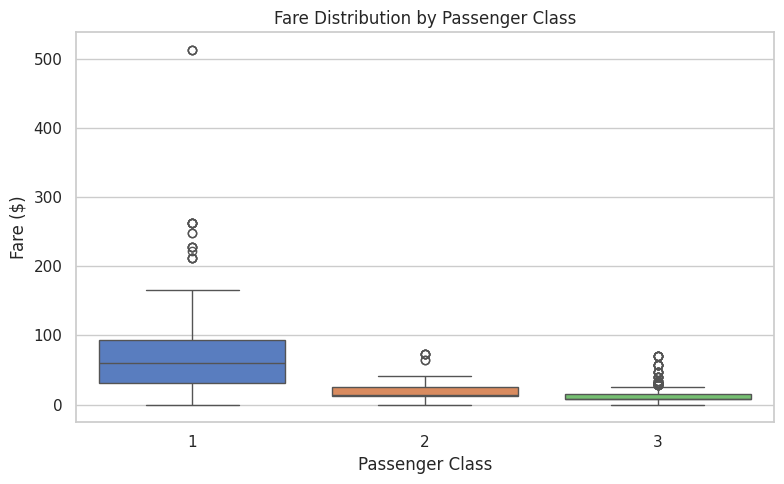

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Pclass', palette='muted', legend=False)
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.tight_layout()
plt.savefig('outputs/boxplot_fare_by_class.png', bbox_inches='tight')
plt.show()

1st class fares are both higher on average and far more spread out (with the most extreme outliers), while 2nd and 3rd class fares are cheaper and more tightly clustered — exactly as expected.

### 4.3 Bar chart — Survival rate by sex and class

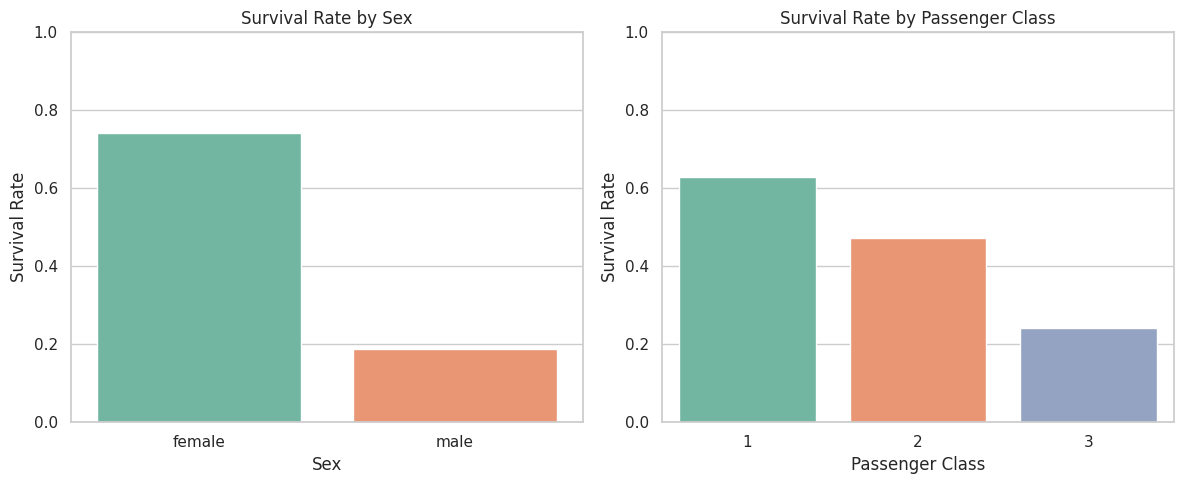

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_survival = df.groupby('Sex')['Survived'].mean()
sns.barplot(x=sex_survival.index, y=sex_survival.values, hue=sex_survival.index,
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

class_survival = df.groupby('Pclass')['Survived'].mean()
sns.barplot(x=class_survival.index, y=class_survival.values, hue=class_survival.index,
            palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('outputs/barchart_survival.png', bbox_inches='tight')
plt.show()

In [11]:
print("Survival rate by sex:")
print(df.groupby('Sex')['Survived'].mean().round(3))
print("\nSurvival rate by class:")
print(df.groupby('Pclass')['Survived'].mean().round(3))

Survival rate by sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


Women survived at a much higher rate than men, and survival rate drops steadily from 1st to 3rd class — both point toward the "women and children first" evacuation norm and unequal access to lifeboats by class.

### 4.4 Correlation heatmap

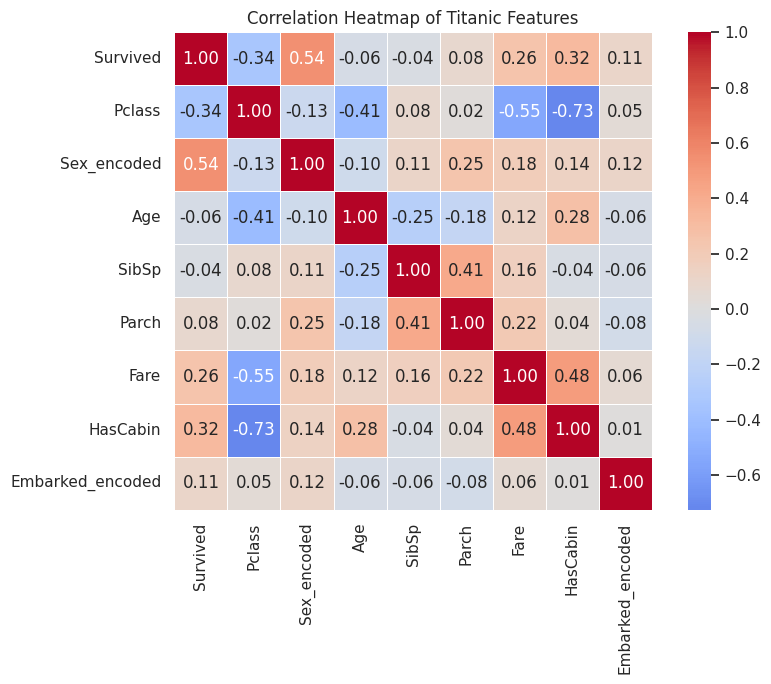

In [12]:
df_corr = df.copy()
df_corr['Sex_encoded'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked_encoded'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

corr_cols = ['Survived', 'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch',
             'Fare', 'HasCabin', 'Embarked_encoded']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [13]:
corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)

Sex_encoded         0.543351
Pclass             -0.338481
HasCabin            0.316912
Fare                0.257307
Embarked_encoded    0.106811
Parch               0.081629
Age                -0.059579
SibSp              -0.035322
Name: Survived, dtype: float64

The strongest correlations with `Survived` are `Sex_encoded` (positive — being female), `Pclass` (negative — higher class number means lower survival), `Fare` (positive), and `HasCabin` (positive, largely overlapping with class/fare).

## 5. Which feature most affects survival, and why?

**Sex is the single strongest predictor of survival**, with `Pclass` and `Fare` close behind (and largely overlapping with each other, since wealthier passengers bought higher-class tickets).

Evidence from this notebook:

- The bar chart shows women survived at roughly **74%**, versus about **19%** for men — a huge gap, the largest split of any category examined here.
- In the correlation heatmap, `Sex_encoded` has the highest-magnitude correlation with `Survived` of any feature.
- `Pclass` and `Fare` are the next most important: 1st-class passengers survived at a much higher rate than 3rd-class passengers, which lines up with the historical account that lifeboats were loaded from the upper decks first and 1st-class cabins had faster access to them.

**Why sex dominates:** the ship's evacuation followed a "women and children first" protocol, which was a policy decision, not a matter of physical circumstance — so it shows up as the cleanest, most consistent split in the data. Class effects layered on top of that (better location on the ship, closer proximity to lifeboats, possibly preferential treatment), which is why `Pclass`/`Fare`/`HasCabin` all correlate with survival too, but less strongly than `Sex`.

If I had to pick one feature to keep if I could only use one for a simple survival model, it would be **`Sex`**, followed closely by **`Pclass`**.


## 6. Summary

- Cleaned missing data in `Age` (grouped median), `Embarked` (mode), and `Cabin` (converted to a `HasCabin` flag, raw column dropped) — no rows were dropped, keeping the full 891-passenger dataset.
- Identified fare outliers using the IQR rule; found a legitimate cluster of high-paying 1st-class passengers rather than data errors.
- Produced 4+ visualizations: an age histogram, a fare-by-class boxplot (plus the outlier-detection boxplots above), a sex/class survival bar chart, and a correlation heatmap.
- Sex is the strongest single predictor of survival, followed by passenger class and fare.
